We have four "types" of data we are visualizing:
- a) Actual perturbation test data 
- b) Predicted perturbation test data (counterfactual of control input)
- c) Actual control (no pert) train data 
- d) Predicted control (no pert) train data (no counterfactual)

Currently, we visualize predictions by fitting a PLS model on actual data (dataypes (a) and (c)) and projecting our predicted data (datatypes (b) and (d)) into this PLS space. With visualization of predictions we have 3 assessments:
1) Overlay of datatype (b) with datatype (a) -- tells us predictions are accurate
2) Separation of datatype (d) from datatype (b) -- tells us counterfactual is working and we get separation in predicted perturbation space
3) Overlay of datatype (d) with datatype(c) -- this *should* come out of both 1 and 2 being true, if there is separation in the actual perturbations. 

We observed the following: In Tahoe, while we were able to achieve visualization assessment (1) we were not able to achieve visualization assessment (2) (and, consequently, (3)). In McCauley, where we've just begung to troubleshoot hyperparameters (so don't expect accurate predictions), we *also* see this in our visual assessment. *However*, our quantitative assessment metrics (DE, and in particular, rank-based) indicate far worse performance in McCauley than Tahoe. This made me **question whether the current visualization framework is too stringent**. 

The current visualization framework does the following: It fits PLS on the actual data (datatypes (a) and (c)), and it projects predicted data (datatypes (d) and (b)) into this embedding. Here, we explore the following:
- i) what the PLS fit is actually telling us about the discriminant features
- ii) whether further projecting to UMAP makes any difference
- iii) whether a less stringent PLS fit on just the predicted datatypes achieves comparable capturing of perturbation signal as PLS on the actual datatypes
- iv) If the above is the case, whether an intermediate stringency PLS fit on both the predicted and actual data simultaneously captures comparable perturbation signal as PSL on the actual data types

TLDR Conclusions:
- Discriminant feature contributions are not uniformly distributed, in line with prev. observations that perturbation signal is weak and difficult for the model to capture, and indicative that this visualization can be quite stringent when projecting predicted onto actual
- It appears that both (iii) and (iv)  do visually achieve the separation we weren't seeing in the current visualization. Though, for (iii), PLS fit assessment indicates a lack of significance.  
- (iv) visually seems to achieve better separation than (iii) even (perhaps driven by the actual data signal). It seems that (iv) can be a good compromise as a visual instead of projecting predicted onto actual.

In [1]:
fn = '14_engaging'

In [2]:
import os
import joblib
import math

import pandas as pd
import numpy as np
from scipy import stats
import scanpy as sc

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from cliffs_delta import cliffs_delta

import torch

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install

In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888


data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"


In [4]:
subset = True

In [5]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
trainer = io.read_pickled_object(os.path.join(data_path, 'trash', fn + author +  '_trainer.pickle'))
mod = trainer.mod


In [6]:
n_adversarial_start = trainer.n_adversarial_start
n_cat_discriminator_train = trainer.n_cat_discriminator_train
n_pert_discriminator_train = trainer.n_pert_discriminator_train

train_stats_df = trainer.stats['train'].copy()

# REMOVE THIS
if 'contrastive_loss_no_collapse_bg' not in train_stats_df.columns:
    train_stats_df['contrastive_loss_no_collapse_bg'] = 0

keep_mask = pd.Series([
    (e >= n_adversarial_start) 
    for e in (train_stats_df.epoch - 1)
])

for col in ['sign_reg_loss']:
    train_stats_df[col] = train_stats_df[col].mask(
        (train_stats_df[col] == 0), 
        np.nan
    )

# DELETE THIS
train_stats_df = train_stats_df.groupby('epoch').mean().reset_index() 

    
cat_col = 'cell_line'
pert_col = 'drug'
ctrl_pert = 'DMSO_TF'
    
train_cells = trainer.X_train.index.tolist()
test_cells = trainer.X_test.index.tolist()

train_conds = sorted(tf_adata.obs.loc[train_cells, :].condition.unique())
test_conds = sorted(tf_adata.obs.loc[test_cells, :].condition.unique())

# subset_size = round(len(train_cells)/(tf_adata.n_obs*0.9), 2)

In [7]:
pert_col = 'drug'
cat_col = 'cell_line'
ctrl_pert = 'DMSO_TF'

In [8]:
# parameters for pls pipeline
pls_component_selection_kwargs = {
    'max_components': 25, 
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': seed
}

pls_assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': True, 
    'get_accuracy_pval': True,
    'n_folds': 5, 
    'seed': seed
}

# Get the reduction(s) for the condition

In [71]:
cond_i = 1
cond = test_conds[cond_i]
cell_line, pert = cond.split('^')
ctrl_cond = cell_line + '^' + ctrl_pert

In [72]:
# pls_fn = os.path.join(
#     data_path, 'trash',
#     '_'.join([author, 'PLSfits', 'seed{}'.format(seed)]) + '.pkl'
# )
# pls_models = joblib.load(pls_fn)
# pls_model = pls_models[cond]['pls_mod']

# mask = tf_adata.obs.condition.isin([cond, ctrl_cond])
# tf_adata_sub = tf_adata[mask].copy()

tf_adata_sub, r2_df = ls.pls_da_pipeline(
    adata = tf_adata,
    pert_ids = [pert, ctrl_pert],
    cat_ids = cell_line,
    n_components = None, # auto-select number of components
    control_confounders = None, # deprecated
    assess_pls_fit = True, # get the final model significance
    pert_col = 'drug',
    cat_col = 'cell_line',
    separate_by = 'perturbation',
    pls_kwargs = None, # default PLSRegression parameters
    component_selection_kwargs = pls_component_selection_kwargs,
    assessment_kwargs = pls_assessment_kwargs,
    covariate_associations = ['drug'], # quantify separation strength in pls space by drug
    run_umap = True,
    file_prefix = None,
    verbose = False,
    n_cores = n_cores,
    seed = seed
)

pls_model = tf_adata_sub.uns['pls']['pls_mod']
enc_Y = tf_adata_sub.uns['pls']['encoder_y']
umap_mod = tf_adata_sub.uns['umap_pls']['umap_pls_mod']
# top_components = [str(i + 1) for i in np.argsort(-pls_model.explained_y_variance_ratio_)[:2]]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:21<00:00,  4.57it/s]


drug


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 283.54it/s]


drug


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 10.49it/s]


Elbow selection via accuracy identified 3 as the optimal number of PLS components
The model fit has a R2Y of 0.43, with p-value 0.010
The model fit has a Q2Y of 0.35, with p-value 0.010
The model fit has a accuracy of 0.77, with p-value 0.010


''

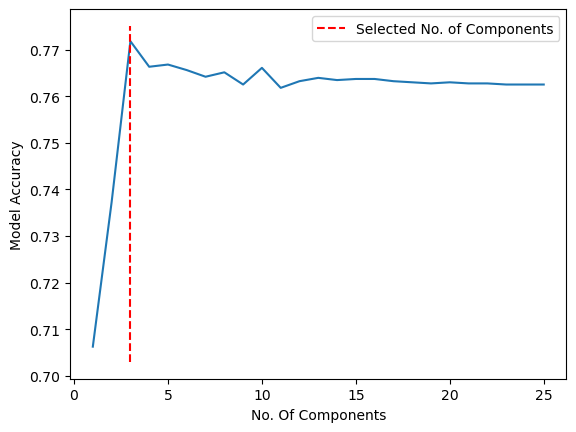

In [73]:
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
      
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
            metric_type, metric_vals['value'], metric_vals['pval']
        ))
fig, ax = plt.subplots()
sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
ymin, ymax = ax.get_ylim()
ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, label = 'Selected No. of Components',
          color = 'red', linestyle = '--'
         )
ax.set_xlabel('No. Of Components')
ax.set_ylabel('Model Accuracy')
ax.legend()
;

In [74]:
predictions_res = io.read_pickled_object(
    os.path.join(data_path, 'trash', fn + '_test_projected_predictions.pickle'))

remove_type = 'none'

tf_adata_predicted = predictions_res[remove_type].copy()
predicted_mask = (tf_adata_predicted.obs.batch != 'actual') 
condition_mask = (tf_adata_predicted.obs.condition.isin([cond, ctrl_cond]))
exclude_mask = (tf_adata_predicted.obs.condition == ctrl_cond) & (tf_adata_predicted.obs.control_for != pert)
mask = predicted_mask & condition_mask & ~exclude_mask

tf_adata_predicted = tf_adata_predicted[mask].copy()

# PLS on Actual Data

## Visualization

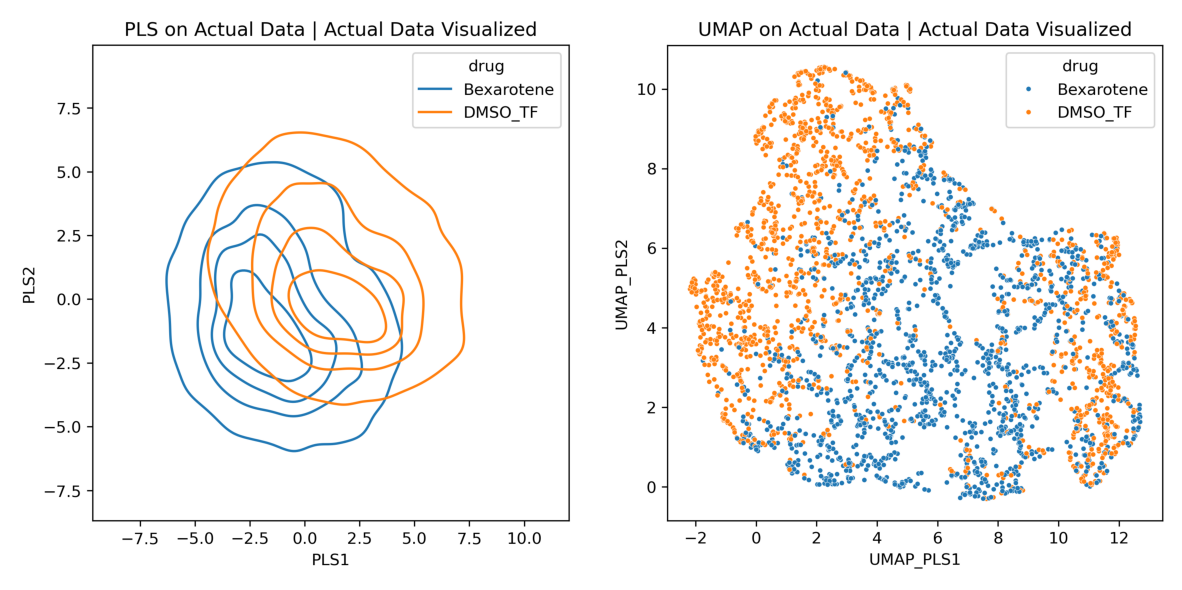

In [75]:
ls.visualize_latent_space(
    adata = tf_adata_sub, 
    latent_label = 'pls', 
    covariates = [pert_col], 
    plot_type = 'contour',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition',
    #components = top_components,
    levels = 5, 
    panel_titles = ['PLS on Actual Data | Actual Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_pls_actual.png'), 
    show_fig = False
)

ls.visualize_latent_space(
    adata = tf_adata_sub, 
    latent_label = 'umap_pls', 
    covariates = [pert_col], 
    legend = True,
    n_frac = 0.8, 
    frac_col = 'condition', 
    panel_titles = ['UMAP on Actual Data | Actual Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_umap_actual.png'), 
    show_fig = False,
)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(os.path.join(data_path, 'trash', cond + '_pls_actual.png')))
ax[1].imshow(mpimg.imread(os.path.join(data_path, 'trash', cond + '_umap_actual.png')))

for ax in ax:
    ax.axis("off")

fig.tight_layout()

## Do the PLS components capture strong separation? Is this reflected in the feature loadings / VIP?

Can we *expect* to see it visually from the first couple components, or is something like UMAP necessary?

In [76]:
pls_feature_importance, pls_stats = ls.assess_pls_separation(
    tf_adata = tf_adata_sub, 
    pls_model = pls_model, 
    enc_Y = enc_Y, 
    pert_col = pert_col, 
    ctrl_pert = ctrl_pert,
    get_pert_separation_stats=True
)

pls_stats.head()

,Y variance explained,"Spearman Correlation (VIP, X loadings)","Pearson Correlation (X scores, Y)"
PLS_1,26.599143,-0.048693,-0.515744
PLS_2,9.240884,-0.226578,-0.303988
PLS_3,6.901549,0.280341,-0.262708


Here, we see that the first few PLS components capture a lot of the Y variance (Y variance explained, Pearson correlation).

In [15]:
pls_stats.abs().iloc[:5, :].corr(method = 'spearman')

,Y variance explained,"Spearman Correlation (VIP, X loadings)","Pearson Correlation (X scores, Y)"
Y variance explained,1.0,1.0,1.0
"Spearman Correlation (VIP, X loadings)",1.0,1.0,1.0
"Pearson Correlation (X scores, Y)",1.0,1.0,1.0


Here, we see that the spearman correlation of VIP and X loadings is strongly associated with this Y variance and Pearson correlation, meaning that the feature weights in those component well reflect the separation (this should inherently follow given what PLS objective is, but useful to see to assess that things aren't too noisy/lacking separation).

/tmp/ipykernel_2163912/251210070.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')


''

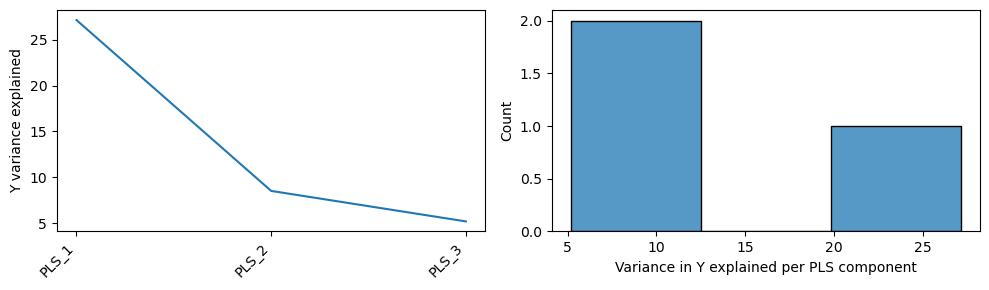

In [16]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 3))

i=0
sns.lineplot(pls_stats['Y variance explained'], ax = ax[i])
ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

i = 1
sns.histplot(pls_stats['Y variance explained'], ax = ax[i])
ax[i].set_xlabel('Variance in Y explained per PLS component')

fig.tight_layout()
;

This tells us that 1) our first PLS component has strong separation and 2) that we can look at either VIP or X loadings features to show how they contribute to separation. 

# Features Driving Separation

## If the feature loadings/VIP reflect this separation, is separation distributed evenly (uniform) across features or limited to a few features driving separation?

If the latter, it will be more stringent to project predictions into this space, as the model needs to really capture the change by just a few features out of the hundreds provided to it. 

## To what extent is separation in PLS reflected in separation in full feature space (is it the same features, is it the same distribution)?



First, let's look at their distribution. If they're very unevenly distributed, only a few values are driving separation. VIP scores and loadings tell use about separation in PLS space, the Cohen's d is calculated on full feature space so tells us more about the separation in full feature space

In [77]:
pls_feature_importance_actual = pls_feature_importance.copy()

''

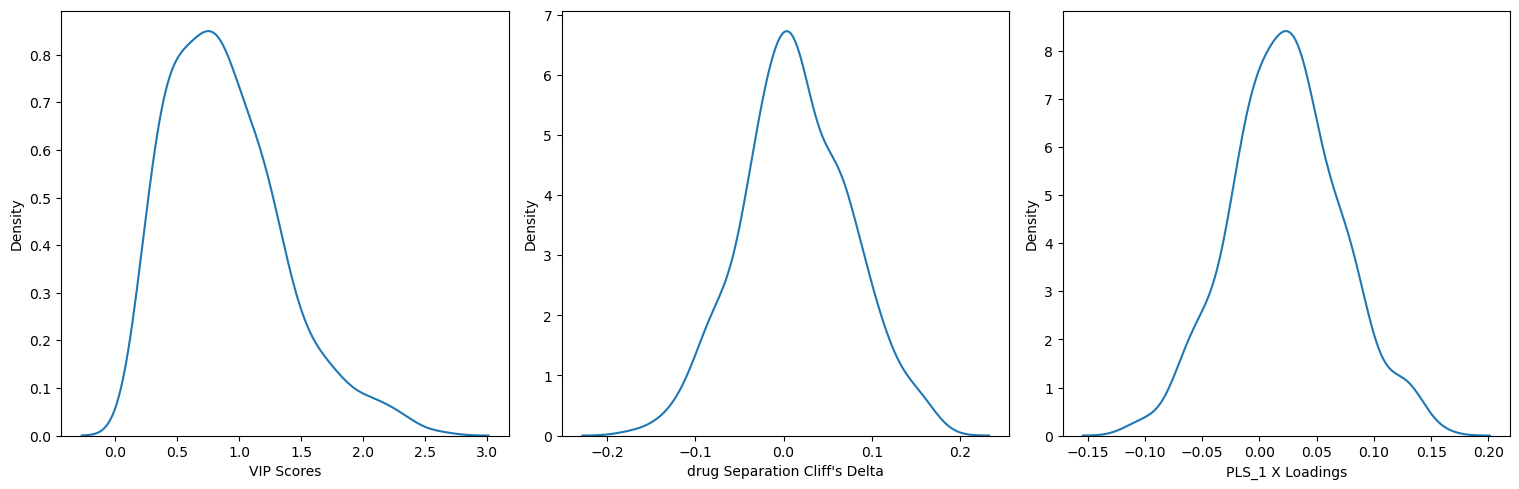

In [18]:
n_components_viz = 1
ncols = n_components_viz + 2
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols * 5.1, 5))

for i in range(ncols):
    if i == 0:
        col = 'VIP'
        x_label = 'VIP Scores'
    elif i == 1:
        col = "{} Separation Cliff's Delta".format(pert_col)
        x_label = col
    else:
        col = 'PLS_{}'.format(i - 1)
        x_label = col + ' X Loadings'
    
    sns.kdeplot(data = pls_feature_importance, x = col, ax = ax[i])
    ax[i].set_xlabel(x_label)
fig.tight_layout()
;


The more uniform the features, the more evenly distributed is the signal of perturbation separation across features. These distributions tell us that, generally speaking, only a few features drive the separation, both in PLS space (VIP loadings, X loadings) and in full feature space (Cliff's delta).

The PLS space lack of uniform separation makes it more challenging for visualizing the predictions of the model when we are projecting the separation. It indicates that perhaps projecting into the existing actual data PLS embedding is too stringent. 

The full feature lack of separation makes it harder for the model to even capture the separation. 

In [19]:
n_components_corr = 2
cols = ['VIP', "{} Separation Cliff's Delta".format(pert_col)]
cols += ['PLS_{}'.format(i+1) for i in range(n_components_corr)]
pls_feature_importance[cols].abs().corr(method = 'spearman')

,VIP,drug Separation Cliff's Delta,PLS_1,PLS_2
VIP,1.000000,0.765369,0.706601,0.355621
drug Separation Cliff's Delta,0.765369,1.000000,0.615011,0.017408
PLS_1,0.706601,0.615011,1.000000,0.120794
PLS_2,0.355621,0.017408,0.120794,1.000000


The high spearman correlation between the Cliff's. Delta and the VIP and PLS loadings tells us that the PLS is reflecting the separation in full feature space reasonably well. However, given that there are only few discriminant features in PLS space, projection into this space may magnify any issues the the model missed and can still be too stringent. 

Instead, we can perhaps see whether scLEMBAS can achieve the same pattern of separation (i.e. latent contrast by re-running PLS on predicted), rather than reproducing the same exact behavior of the discriminant features (i.e., projecting into PLS on actual). 

In [20]:
# top_n_features = 5
# n_components_viz = 1

# ncols = top_n_features
# nrows = n_components_viz + 2

# mid_cols = ncols/2
# title_j = int(math.floor(mid_cols + 0.5)) if mid_cols >= 0 else int(math.ceil(mid_cols - 0.5))
# title_j -= 1

# fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows))


# for i in range(nrows):
#     if i == 0:
#         col = 'VIP'
#     elif i == 1:
#         col = "{} Separation Cliff's Delta".format(pert_col)
#     else:
#         col = 'PLS_{}'.format(i-1)

#     top_features = pls_feature_importance.sort_values(by = col, key = abs, ascending = False).index.tolist()[:top_n_features]

#     for (j, top_feature) in enumerate(top_features):
#         viz_df = tf_adata_sub[:, top_feature].to_df()
#         viz_df.columns = ['feature_expression']
#         viz_df[pert_col] = tf_adata_sub.obs[pert_col]

#         sns.boxplot(data = viz_df, y='feature_expression', x = 'drug', ax = ax[i,j])
#         ax[i,j].set_ylabel(top_feature + ' Expression')
#         ax[i,j].set_xlabel(pert_col)
        
#         mwu_pval = pls_feature_importance.loc[top_feature, '{} Separation MWU p-val'.format(pert_col)]
#         cd = pls_feature_importance.loc[top_feature, "{} Separation Cliff's Delta".format(pert_col)]
        
#         ax[i,j].annotate('MWU p-val: {:3f}'.format(mwu_pval), 
#                         xy=(1, 0.975), xycoords='axes fraction', ha='right', va='top')
#         ax[i,j].annotate("Cliff's Deta: {:3f}".format(cd), 
#                         xy=(1, 0.925), xycoords='axes fraction', ha='right', va='top')
        
        
#     ax[i, title_j].set_title('Rank-ordered by {}'.format(col), fontsize = 20, pad = 30)


# fig.tight_layout()
# ;


# Projection of Predicted Data into PLS on Actual: Despite only a few discriminant features, can UMAP aggregation across all PLS components capture separation when projecting predicted into actual?

While the above results indicate that this is unlikely, here we want to see if we further project to the UMAP space rather than just the PLS space, whether we are able to see differences in predicted features. 

Let's project our predicted values into the PLS and UMAP spaces:

In [78]:
palette = list(np.array(list(sns.color_palette('Set1')))[[0,2]])

In [79]:
X_in_pred = tf_adata_predicted.X.copy()

X_lp = pls_model.transform(X_in_pred)
X_umap = umap_mod.transform(X_lp)

tf_adata_predicted.obsm['X_pls'] = X_lp
tf_adata_predicted.obsm['X_umap_pls'] = X_umap

In [80]:
ls.visualize_latent_space(
    adata = tf_adata_predicted, 
    latent_label = 'pls', 
    covariates = [pert_col], 
    plot_type = 'contour',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition',
    palette = palette, 
    #components = top_components,
    levels = 5, 
    panel_titles = ['PLS on Actual Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_pls_projected_predicted.png'), 
    show_fig = False
)


ls.visualize_latent_space(
    adata = tf_adata_predicted, 
    latent_label = 'umap_pls', 
    covariates = [pert_col], 
    legend = True,
    n_frac = 1, 
    frac_col = 'condition', 
    plot_type = 'scatter', 
    palette = palette,
    panel_titles = ['UMAP on Actual Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_umap_projected_predicted.png'), 
    show_fig = False
)

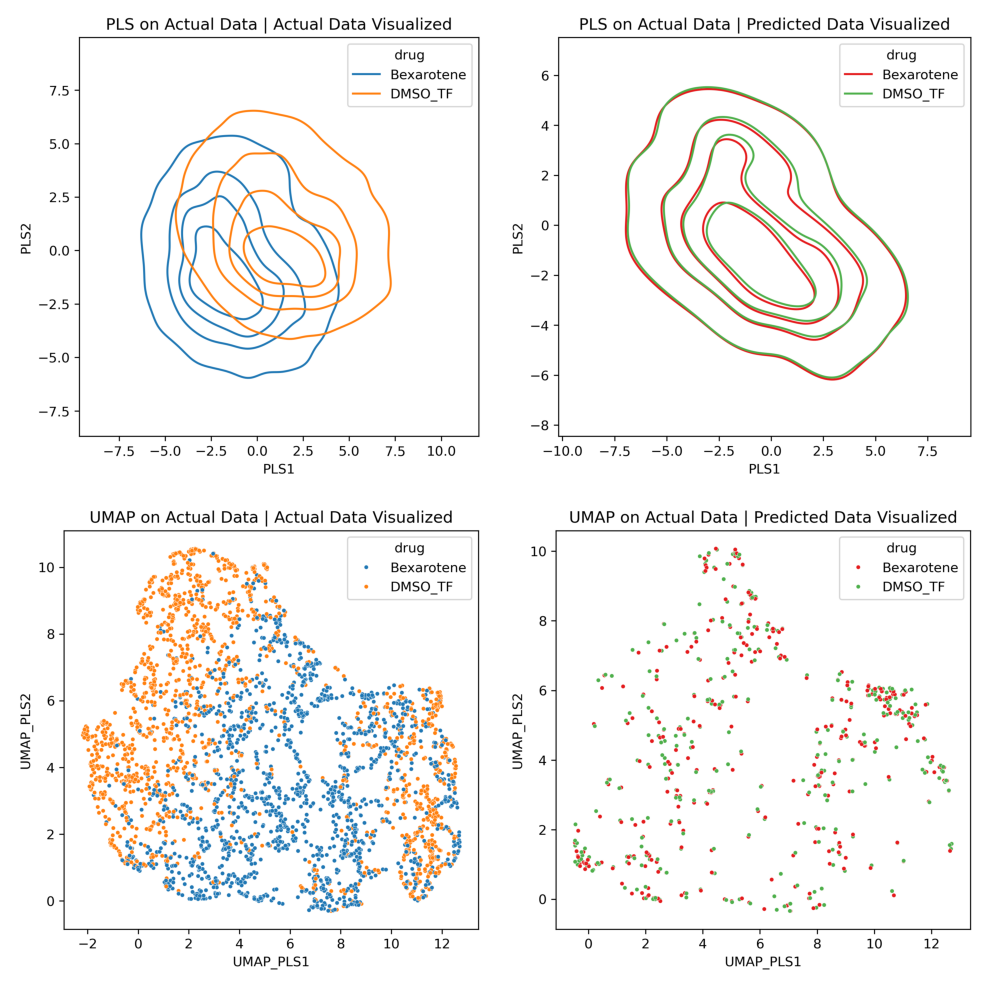

In [81]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()

image_files = [
    os.path.join(data_path, 'trash', cond + '_pls_actual.png'),
    os.path.join(data_path, 'trash', cond + '_pls_projected_predicted.png'),
    os.path.join(data_path, 'trash', cond + '_umap_actual.png'),
    os.path.join(data_path, 'trash', cond + '_umap_projected_predicted.png'),
]

for i, fname in enumerate(image_files):
    img = mpimg.imread(fname)
    ax[i].imshow(img)
    ax[i].axis("off")

fig.tight_layout()
fig.tight_layout()


Simply projecting into UMAP doesn't increase separation from PLS in the predicted data projections. This makes sense since PLS1 captures much of the separation anyways (and only 3 pls components were used). 

# Separate PLS on Predicted Data: Is separation achieved in the predicted features, independent of what is happening in the actual features?


We use the same number of components as in the actual data.

In [82]:
tf_adata_sub_predicted, r2_df = ls.pls_da_pipeline(
    adata = tf_adata_predicted,
    pert_ids = [pert, ctrl_pert],
    cat_ids = cell_line,
    n_components = pls_model.n_components, #16, #None, # auto-select number of components
    control_confounders = None, # deprecated
    assess_pls_fit = True, # get the final model significance
    pert_col = 'drug',
    cat_col = 'cell_line',
    separate_by = 'perturbation',
    pls_kwargs = None, # default PLSRegression parameters
    component_selection_kwargs = pls_component_selection_kwargs,
    assessment_kwargs = pls_assessment_kwargs,
    covariate_associations = ['drug'], # quantify separation strength in pls space by drug
    run_umap = True,
    file_prefix = None,
    verbose = False,
    n_cores = n_cores,
    seed = seed
)

pls_model_predicted = tf_adata_sub_predicted.uns['pls']['pls_mod']
enc_Y_predicted = tf_adata_sub_predicted.uns['pls']['encoder_y']
umap_mod_predicted = tf_adata_sub_predicted.uns['umap_pls']['umap_pls_mod']
# top_components_predicted = [str(i + 1) for i in np.argsort(-pls_model_predicted.explained_y_variance_ratio_)[:2]]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 21.71it/s]


drug


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 384.74it/s]


drug


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 11.44it/s]


In [83]:
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model_predicted.n_components))
      
for metric_type, metric_vals in pls_model_predicted.assessment_metrics.items():
    if metric_type != 'R2X':
        print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
            metric_type, metric_vals['value'], metric_vals['pval']
        ))

if pls_model_predicted.metric_per_component is not None:
    fig, ax = plt.subplots()
    sns.lineplot(y = pls_model_predicted.metric_per_component, x = range(1, len(pls_model_predicted.metric_per_component) + 1), ax = ax)
    ymin, ymax = ax.get_ylim()
    ax.vlines(x = pls_model_predicted.n_components, ymin = ymin, ymax = ymax, label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax.set_xlabel('No. Of Components')
    ax.set_ylabel('Model Accuracy')
    ax.legend()
    ;

Elbow selection via accuracy identified 3 as the optimal number of PLS components
The model fit has a R2Y of 0.18, with p-value 0.851
The model fit has a Q2Y of -0.54, with p-value 1.000
The model fit has a accuracy of 0.31, with p-value 1.000


## Visualization

In [84]:
ls.visualize_latent_space(
    adata = tf_adata_sub_predicted, 
    latent_label = 'pls', 
    covariates = [pert_col], 
    plot_type = 'contour',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition', 
    palette = palette, 
    #components = top_components_predicted,
    levels = 5, 
    panel_titles = ['PLS on Predicted Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_pls_embedded_predicted.png'), 
    show_fig = False
    
)

ls.visualize_latent_space(
    adata = tf_adata_sub_predicted, 
    latent_label = 'umap_pls', 
    covariates = [pert_col], 
    plot_type = 'scatter',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition', 
    palette = palette, 
    panel_titles = ['UMAP on Predicted Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_umap_embedded_predicted.png'), 
    show_fig = False
)



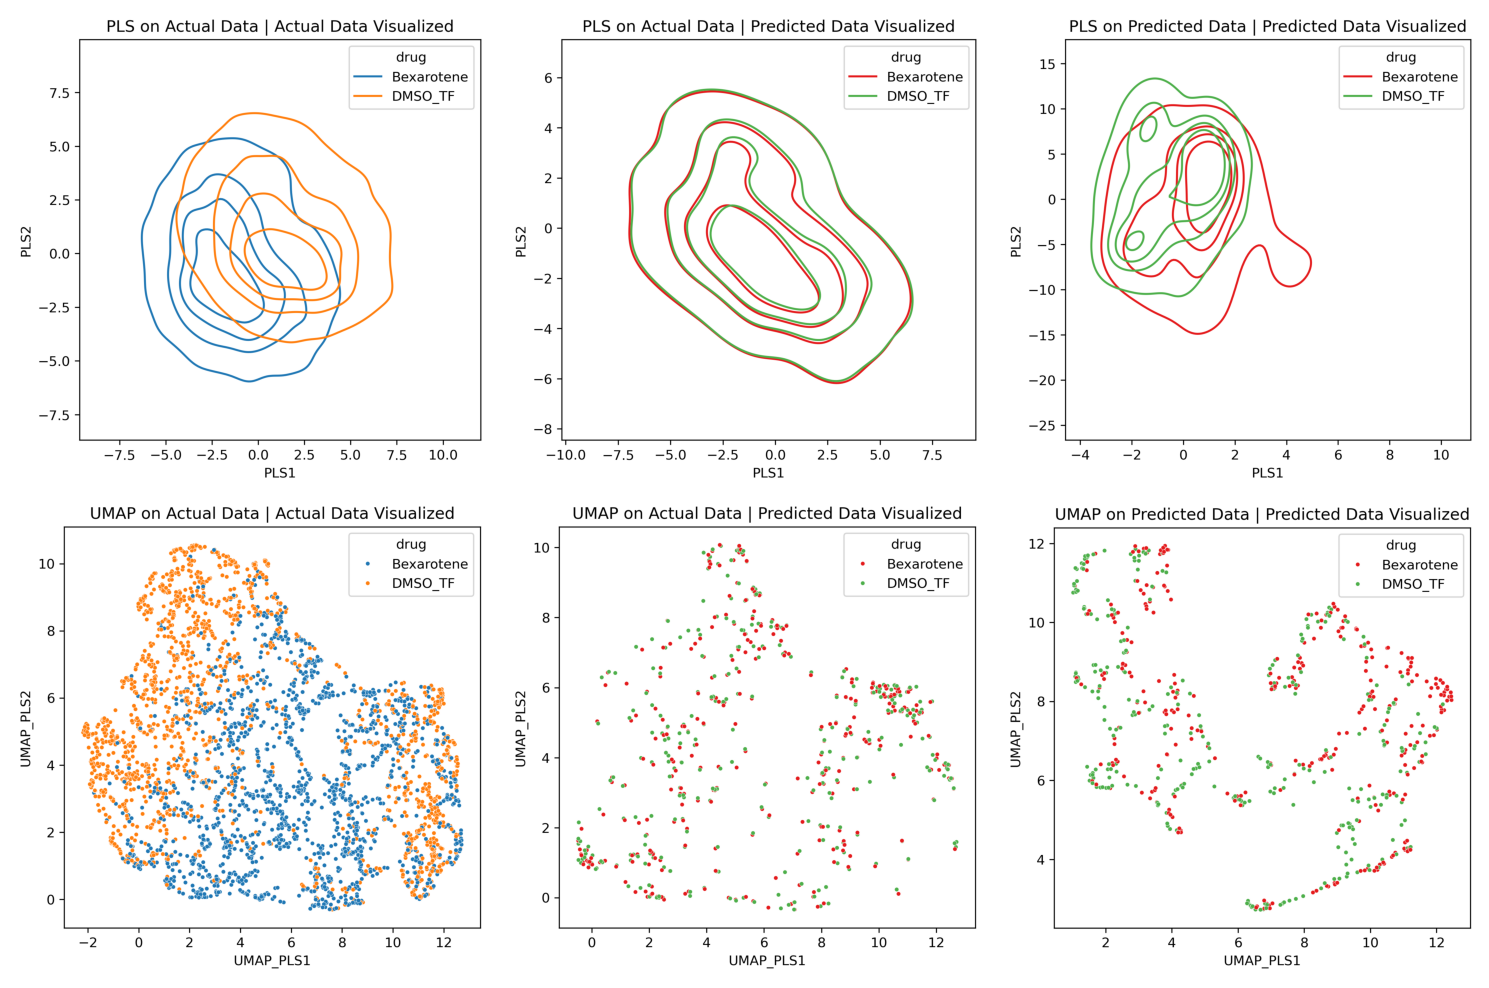

In [85]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

image_files = [
    os.path.join(data_path, 'trash', cond + '_pls_actual.png'),
    os.path.join(data_path, 'trash', cond + '_pls_projected_predicted.png'),
    os.path.join(data_path, 'trash', cond + '_pls_embedded_predicted.png'),
    os.path.join(data_path, 'trash', cond + '_umap_actual.png'),
    os.path.join(data_path, 'trash', cond + '_umap_projected_predicted.png'),
    os.path.join(data_path, 'trash', cond + '_umap_embedded_predicted.png')
]

for i, fname in enumerate(image_files):
    img = mpimg.imread(fname)
    ax[i].imshow(img)
    ax[i].axis("off")

fig.tight_layout()


**Visually**, PLS separation on the predicted data, run just on the predicted, has stronger separation than on the predicted data projected onto the PLS model fit on the actual data. While it is not as strong as the separation of the actual data, this shows visually that the model is capturing some separation by perturbation, which is reflected in our downstream quantitative metrics. This is more strongly reflected in the UMAP, ofcourse. Unlike the projection onto UMAP, we definitely see separation.

**However**, the model is not significant by Q2Y, R2Y, and accuracy p-values. 

## Stats - Comparison to PLS on Actual

In [29]:
pls_feature_importance_predicted, pls_stats_predicted = ls.assess_pls_separation(
    tf_adata = tf_adata_sub_predicted, 
    pls_model = pls_model_predicted, 
    enc_Y = enc_Y_predicted, 
    pert_col = pert_col, 
    ctrl_pert = ctrl_pert,
    get_pert_separation_stats=True
)

pls_stats_predicted.head()

,Y variance explained,"Spearman Correlation (VIP, X loadings)","Pearson Correlation (X scores, Y)"
PLS_1,2.815980,0.537886,0.167809
PLS_2,6.225611,0.523102,-0.249512
PLS_3,4.416637,-0.061131,-0.210158


/tmp/ipykernel_2163912/4049678597.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')


''

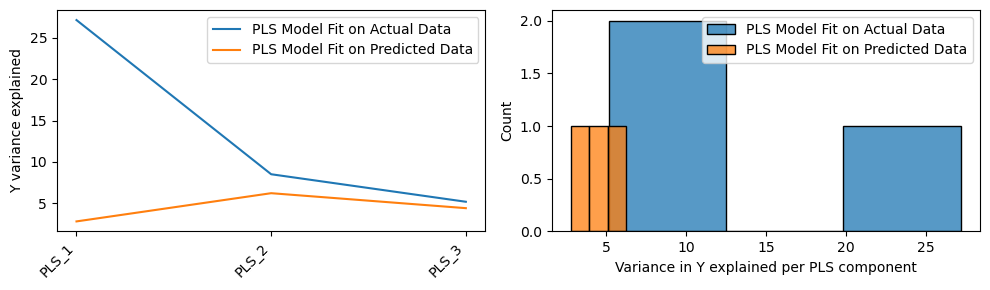

In [30]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 3))

i=0
sns.lineplot(pls_stats['Y variance explained'], ax = ax[i], label = 'PLS Model Fit on Actual Data')
sns.lineplot(pls_stats_predicted['Y variance explained'],  ax = ax[i], label = 'PLS Model Fit on Predicted Data')


ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

i = 1
sns.histplot(pls_stats['Y variance explained'], ax = ax[i], label = 'PLS Model Fit on Actual Data')
sns.histplot(pls_stats_predicted['Y variance explained'], ax = ax[i], label = 'PLS Model Fit on Predicted Data')
ax[i].set_xlabel('Variance in Y explained per PLS component')
ax[i].legend()

fig.tight_layout()
;

We can see that the variance in Y (perturbation) is more evenly spread across PLS components when fit on the predicted data. This also tells us that visualizing just the first 2 components in this case isn't necessarily telling of whether perturbation separation is being captured. 

It also shows that, again, perturbation separation is likely weaker in the predicted data.

These do seem to have different latent structures..

In [31]:
fit_types = {'PLS Model Fit on Actual Data': pls_feature_importance, 
            'PLS Model Fit on Predicted Data': pls_feature_importance_predicted}

''

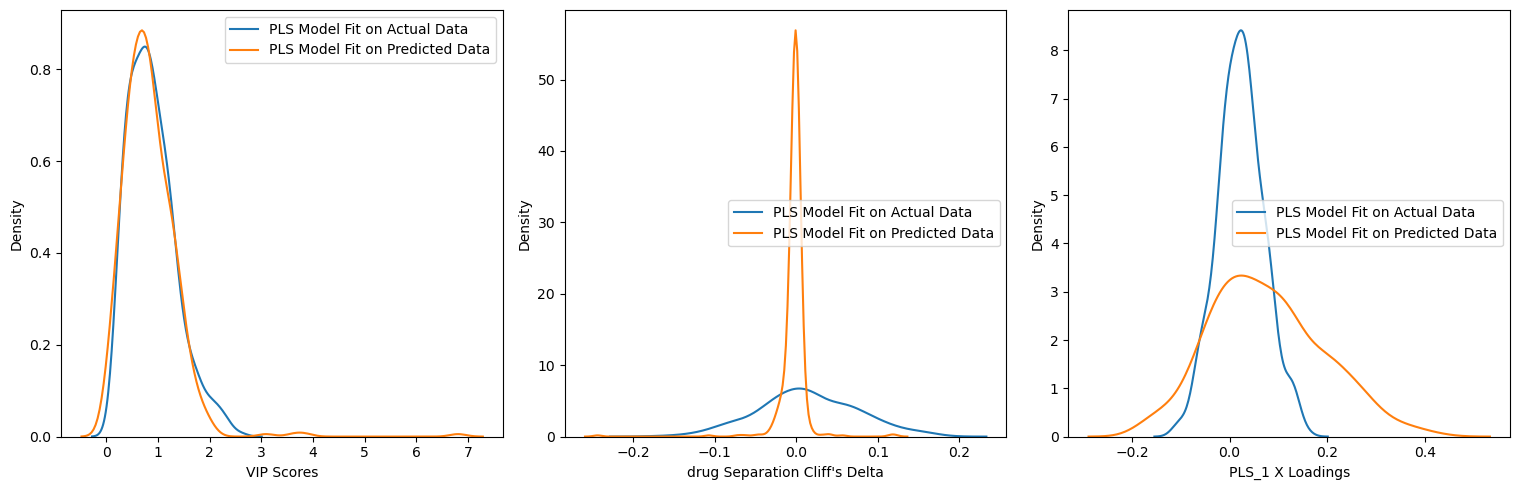

In [32]:
n_components_viz = 1
ncols = n_components_viz + 2
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols * 5.1, 5))



for fit_type, pfi in fit_types.items():
    for i in range(ncols):
        if i == 0:
            col = 'VIP'
            x_label = 'VIP Scores'
        elif i == 1:
            col = "{} Separation Cliff's Delta".format(pert_col)
            x_label = col
        else:
            col = 'PLS_{}'.format(i - 1)
            x_label = col + ' X Loadings'

        sns.kdeplot(data = pfi, x = col, ax = ax[i], label = fit_type)
        ax[i].set_xlabel(x_label)
        ax[i].legend()
fig.tight_layout()
;


We can see that in PLS space, the VIP scores of the predicted data is similarly distributed. However, in the full feature space (cliff's delta), it is more narrowly distributed, meaning the separation is captured in fewer featurs. But the fact that it's much better in PLS space says that there are still multivariate effects (also explained why components have variance spread more evenly). 

The X loadings are less narrowly distributed perhaps because each early component contributes less to variance in the predicted data. 


# PLS Fit on Predicted + Actual

Ok, we saw that 1) projecting predicted onto actual in PLS space does not show separation in predicted, but 2) PLS on predicted only *does* show separation, though not significantly. Is there an intermediate stingency in which we can fit a new PLS on both the predicted and actual and see consistent separation, as well as significance?

In [33]:
tf_adata_actual = tf_adata.copy()
tf_adata_actual.obs['batch'] = 'actual'

predictions_res = io.read_pickled_object(
    os.path.join(data_path, 'trash', fn + '_test_projected_predictions.pickle'))


tf_adata_predicted = predictions_res[remove_type].copy()
predicted_mask = (tf_adata_predicted.obs.batch != 'actual') 
condition_mask = (tf_adata_predicted.obs.condition.isin([cond, ctrl_cond]))
exclude_mask = (tf_adata_predicted.obs.condition == ctrl_cond) & (tf_adata_predicted.obs.control_for != pert)
mask = predicted_mask & condition_mask & ~exclude_mask

tf_adata_predicted = tf_adata_predicted[mask].copy()

tf_adata_merged = sc.concat([tf_adata_actual, tf_adata_predicted])
del tf_adata_merged.obsm['X_pls']

In [34]:
tf_adata_sub, r2_df = ls.pls_da_pipeline(
    adata = tf_adata_merged,
    pert_ids = [pert, ctrl_pert],
    cat_ids = cell_line,
    n_components = pls_model.n_components, #None, # auto-select number of components
    control_confounders = None, # deprecated
    assess_pls_fit = True, # get the final model significance
    pert_col = 'drug',
    cat_col = 'cell_line',
    separate_by = 'perturbation',
    pls_kwargs = None, # default PLSRegression parameters
    component_selection_kwargs = pls_component_selection_kwargs,
    assessment_kwargs = pls_assessment_kwargs,
    covariate_associations = None, #['drug'], # quantify separation strength in pls space by drug
    run_umap = True,
    file_prefix = None,
    verbose = False,
    n_cores = n_cores,
    seed = seed
)


pls_model = tf_adata_sub.uns['pls']['pls_mod']
enc_Y = tf_adata_sub.uns['pls']['encoder_y']
umap_mod = tf_adata_sub.uns['umap_pls']['umap_pls_mod']
# top_components = [str(i + 1) for i in np.argsort(-pls_model.explained_y_variance_ratio_)[:2]]

tf_adata_sub_actual = tf_adata_sub[tf_adata_sub.obs.batch == 'actual'].copy()
tf_adata_sub_predicted = tf_adata_sub[tf_adata_sub.obs.batch != 'actual'].copy()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.92it/s]


In [35]:
print('Elbow selection via accuracy identified {} as the optimal number of PLS components'.format(pls_model.n_components))
      
for metric_type, metric_vals in pls_model.assessment_metrics.items():
    if metric_type != 'R2X':
        print('The model fit has a {} of {:.2f}, with p-value {:.3f}'.format(
            metric_type, metric_vals['value'], metric_vals['pval']
        ))
        
if pls_model.metric_per_component is not None:
    fig, ax = plt.subplots()
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax)
    ymin, ymax = ax.get_ylim()
    ax.vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    ax.set_xlabel('No. Of Components')
    ax.set_ylabel('Model Accuracy')
    ax.legend()
    ;

Elbow selection via accuracy identified 3 as the optimal number of PLS components
The model fit has a R2Y of 0.33, with p-value 0.010
The model fit has a Q2Y of 0.24, with p-value 0.010
The model fit has a accuracy of 0.71, with p-value 0.010


The model fit on both the predicted and actual is significant. 

In [36]:
ls.visualize_latent_space(
    adata = tf_adata_sub_actual, 
    latent_label = 'pls', 
    covariates = [pert_col], 
    plot_type = 'contour',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition',
#     palette = palette, 
    #components = top_components,
    levels = 5, 
    panel_titles = ['PLS on Actual + Predicted Data | Actual Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_pls_embedded_actual.png'), 
    show_fig = False
)


ls.visualize_latent_space(
    adata = tf_adata_sub_actual, 
    latent_label = 'umap_pls', 
    covariates = [pert_col], 
    legend = True,
    n_frac = 1, 
    frac_col = 'condition', 
    plot_type = 'scatter', 
#     palette = palette,
    panel_titles = ['UMAP on Actual + Predicted Data | Actual Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_umap_embedded_actual.png'), 
    show_fig = False
)


ls.visualize_latent_space(
    adata = tf_adata_sub_predicted, 
    latent_label = 'pls', 
    covariates = [pert_col], 
    plot_type = 'contour',
    legend = True,
    n_frac = 1, 
    frac_col = 'condition',
    palette = palette, 
    #components = top_components,
    levels = 5, 
    panel_titles = ['PLS on Actual + Predicted Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_pls_embedded_predicted.png'), 
    show_fig = False
)


ls.visualize_latent_space(
    adata = tf_adata_sub_predicted, 
    latent_label = 'umap_pls', 
    covariates = [pert_col], 
    legend = True,
    n_frac = 1, 
    frac_col = 'condition', 
    plot_type = 'scatter', 
    palette = palette,
    panel_titles = ['UMAP on Actual + Predicted Data | Predicted Data Visualized'],
    file_name = os.path.join(data_path, 'trash', cond + '_umap_embedded_predicted.png'), 
    show_fig = False
)

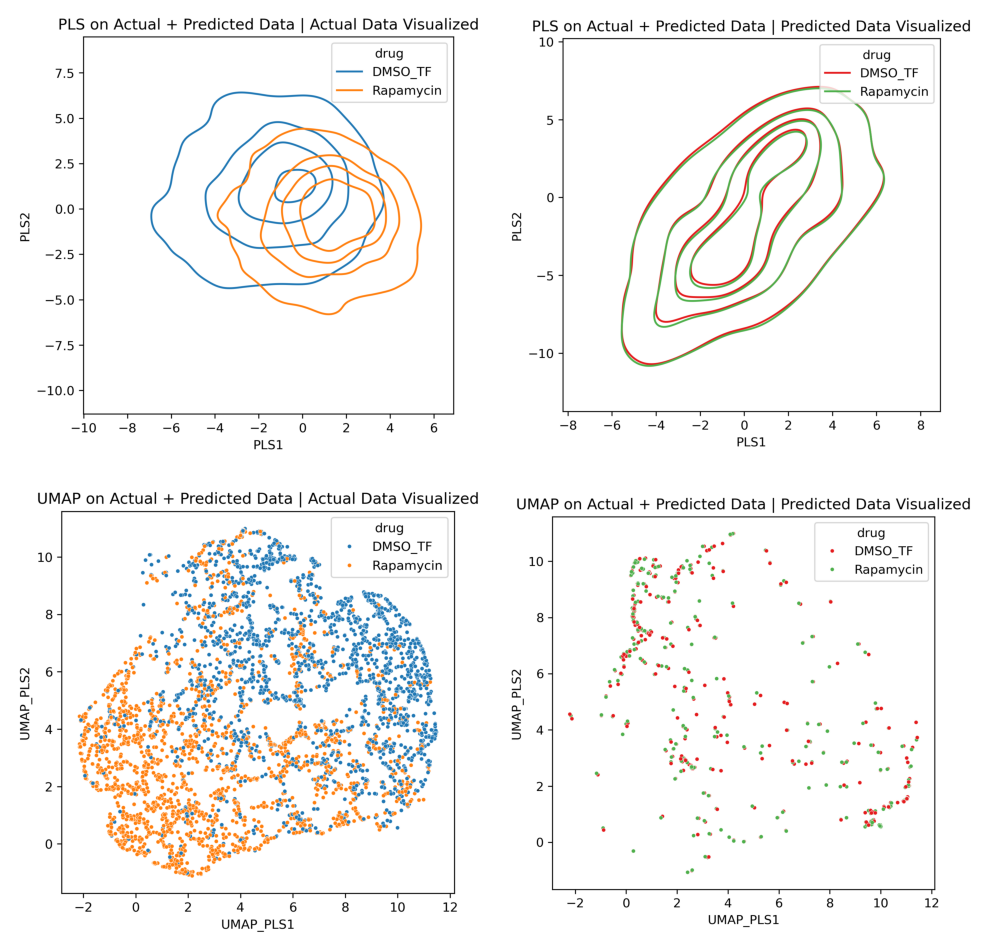

In [37]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()

image_files = [
    os.path.join(data_path, 'trash', cond + '_pls_embedded_actual.png'),
    os.path.join(data_path, 'trash', cond + '_pls_embedded_predicted.png'),
    os.path.join(data_path, 'trash', cond + '_umap_embedded_actual.png'),
    os.path.join(data_path, 'trash', cond + '_umap_embedded_predicted.png'),
]

for i, fname in enumerate(image_files):
    img = mpimg.imread(fname)
    ax[i].imshow(img)
    ax[i].axis("off")

fig.tight_layout()
fig.tight_layout()

We can see at this intermediate stringency of visualization, we are achieving separation in UMAP but not PLS space. This tells us that the separation is in fact real and accurate, reflecting our downstream metrics. 

In [38]:
pls_feature_importance, pls_stats = ls.assess_pls_separation(
    tf_adata = tf_adata_sub, 
    pls_model = pls_model, 
    enc_Y = enc_Y, 
    pert_col = pert_col, 
    ctrl_pert = ctrl_pert,
    get_pert_separation_stats=True
)

pls_stats.head()

,Y variance explained,"Spearman Correlation (VIP, X loadings)","Pearson Correlation (X scores, Y)"
PLS_1,20.327365,0.412926,-0.450859
PLS_2,7.115839,0.294283,0.266755
PLS_3,5.073501,0.095096,-0.225244


/tmp/ipykernel_2163912/251210070.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')


''

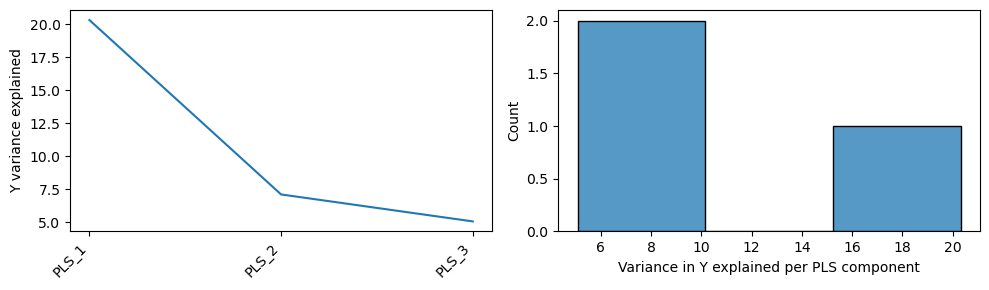

In [39]:
fig, ax = plt.subplots(ncols = 2, figsize = (10, 3))

i=0
sns.lineplot(pls_stats['Y variance explained'], ax = ax[i])
ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

i = 1
sns.histplot(pls_stats['Y variance explained'], ax = ax[i])
ax[i].set_xlabel('Variance in Y explained per PLS component')

fig.tight_layout()
;

In [40]:
fit_types = {'PLS Model Fit on Actual Data': pls_feature_importance_actual, 
            'PLS Model Fit on Actual + Predicted Data': pls_feature_importance}

''

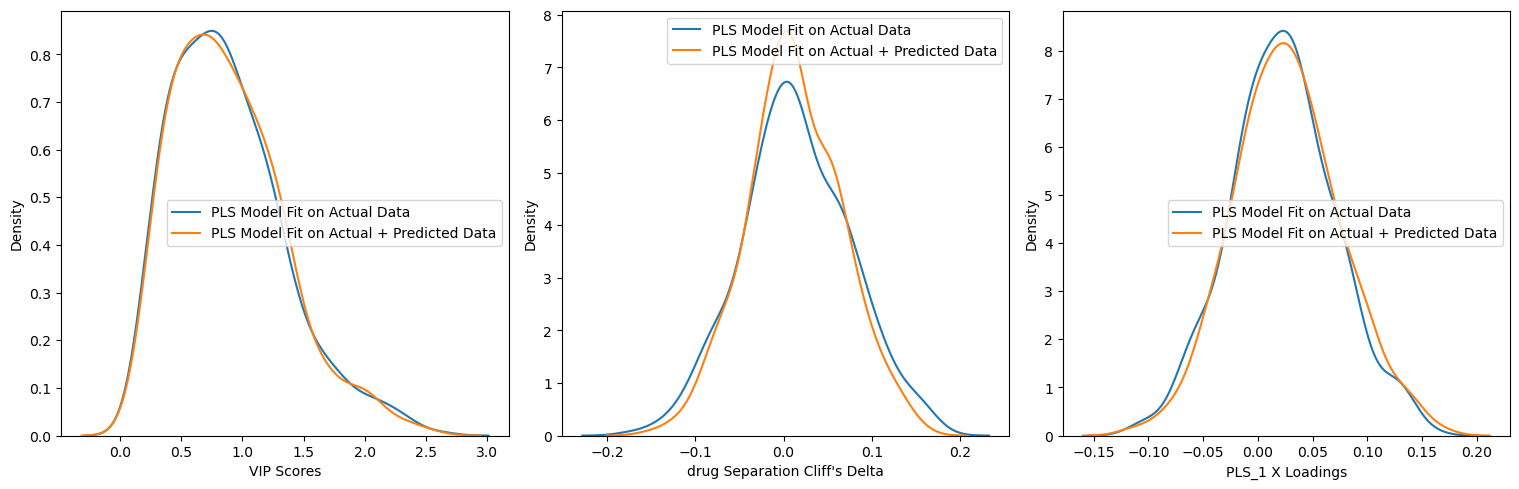

In [41]:
n_components_viz = 1
ncols = n_components_viz + 2
fig, ax = plt.subplots(ncols = ncols, figsize = (ncols * 5.1, 5))



for fit_type, pfi in fit_types.items():
    for i in range(ncols):
        if i == 0:
            col = 'VIP'
            x_label = 'VIP Scores'
        elif i == 1:
            col = "{} Separation Cliff's Delta".format(pert_col)
            x_label = col
        else:
            col = 'PLS_{}'.format(i - 1)
            x_label = col + ' X Loadings'

        sns.kdeplot(data = pfi, x = col, ax = ax[i], label = fit_type)
        ax[i].set_xlabel(x_label)
        ax[i].legend()
fig.tight_layout()
;


Distributions of variance explained and feature contributions also returned to what they were like in the actual data. 

Altogether, this tells us that perhaps trying to project the predicted onto the actual data is *too* stringent of an eyeball test metric, but re-running the embedding jointly on both the predicted and actual can serve as an accurate proxy of model performance. 

In [70]:
# actual_test = pd.DataFrame(tf_adata_sub_actual.X)
# actual_test['drug'] = tf_adata_sub_actual.obs['drug'].tolist()


# predicted_test = pd.DataFrame(tf_adata_sub_predicted.X)
# predicted_test['drug'] = tf_adata_sub_predicted.obs['drug'].tolist()


# fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

# j = 0
# sns.kdeplot(data = actual_test, 
#             x = 2,
#             hue = 'drug', ax = ax[j])
# ax[j].set_title('Actual')

# j = 1
# sns.kdeplot(data = predicted_test, 
#             x = 2,
#             hue = 'drug', ax = ax[j])
# ax[j].set_title('Predicted')

# fig.tight_layout()
# ;